# Mutual Fund Data Analysis (EDA)

### Bluestock Internship Project

**Objective**

Analyze Indian mutual fund datasets to identify trends in:

- NAV
- AUM
- SIP
- Category inflows
- Investor behavior
- Portfolio allocation
- Fund performance

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Plotly

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

print(nav.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [3]:
# Load all datasets

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [4]:
print("NAV")
display(nav.head())

print("AUM")
display(aum.head())

print("SIP")
display(sip.head())

print("Category")
display(category.head())

print("Investor")
display(investor.head())

print("Performance")
display(performance.head())

print("Portfolio")
display(portfolio.head())

NAV


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


AUM


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


SIP


...

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


Performance


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


Portfolio


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [5]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Investor": investor,
    "Performance": performance,
    "Portfolio": portfolio,
}

for name, df in datasets.items():
    print(f"\n{name} Columns:")
    print(df.columns.tolist())


NAV Columns:
['amfi_code', 'date', 'nav']

AUM Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category Columns:
['month', 'category', 'net_inflow_crore']

Investor Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Performance Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Portfolio Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [6]:
# Convert date column into datetime

nav["date"] = pd.to_datetime(nav["date"])

print(nav.info())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None


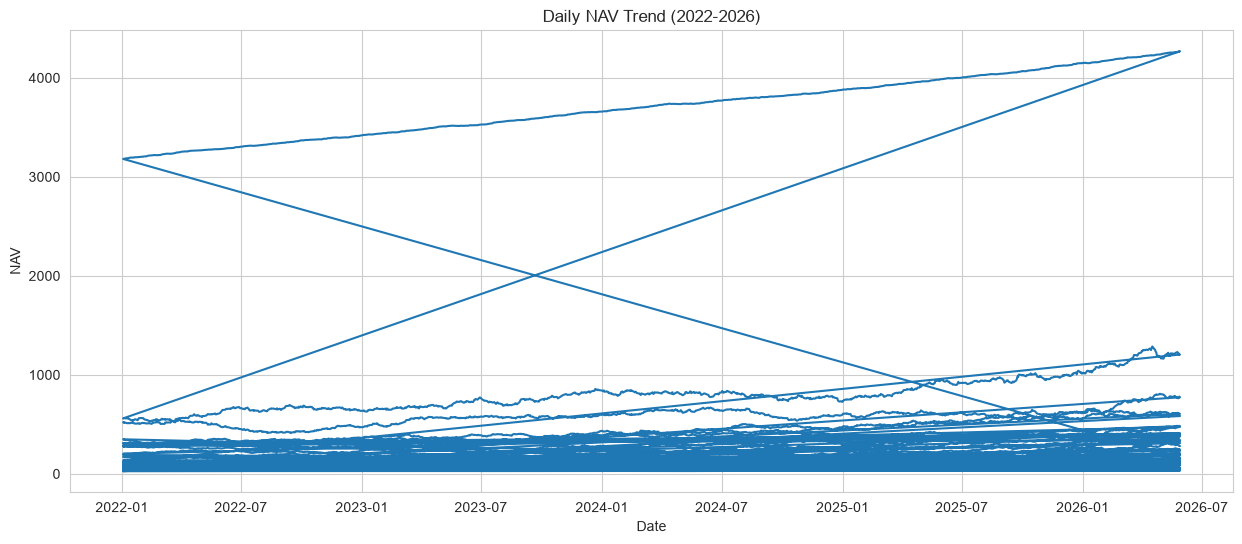

In [7]:
plt.figure(figsize=(15,6))

plt.plot(nav["date"], nav["nav"])

plt.title("Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

## Insight 1

- NAV generally increased over time.
- There are short-term fluctuations, but the long-term trend is upward.

In [9]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

In [10]:
print(nav.shape)

print(nav["amfi_code"].nunique())

print(nav.sort_values(["amfi_code", "date"]).head(20))

(46000, 3)
40
    amfi_code       date       nav
0      100016 2022-01-03  520.4608
1      100016 2022-01-04  515.0971
2      100016 2022-01-05  521.7239
3      100016 2022-01-06  515.7880
4      100016 2022-01-07  515.1639
5      100016 2022-01-10  510.7136
6      100016 2022-01-11  513.5542
7      100016 2022-01-12  512.3195
8      100016 2022-01-13  510.2445
9      100016 2022-01-14  514.3636
10     100016 2022-01-17  514.7627
11     100016 2022-01-18  517.3803
12     100016 2022-01-19  513.1866
13     100016 2022-01-20  507.1294
14     100016 2022-01-21  507.8710
15     100016 2022-01-24  506.7062
16     100016 2022-01-25  509.7762
17     100016 2022-01-26  509.6800
18     100016 2022-01-27  510.8661
19     100016 2022-01-28  503.8641


In [11]:
nav.sort_values(by="nav", ascending=False).head(10)

,amfi_code,date,nav
36799,120844,2026-05-29,4268.5497
36798,120844,2026-05-28,4266.9021
36797,120844,2026-05-27,4264.9256
36796,120844,2026-05-26,4262.3302
36794,120844,2026-05-22,4260.3220
36793,120844,2026-05-21,4259.2780
36795,120844,2026-05-25,4259.2727
36792,120844,2026-05-20,4258.9179
36791,120844,2026-05-19,4256.2918
36788,120844,2026-05-14,4255.9472


In [12]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Check years
print(aum["year"].unique())

[2022 2023 2024 2025]


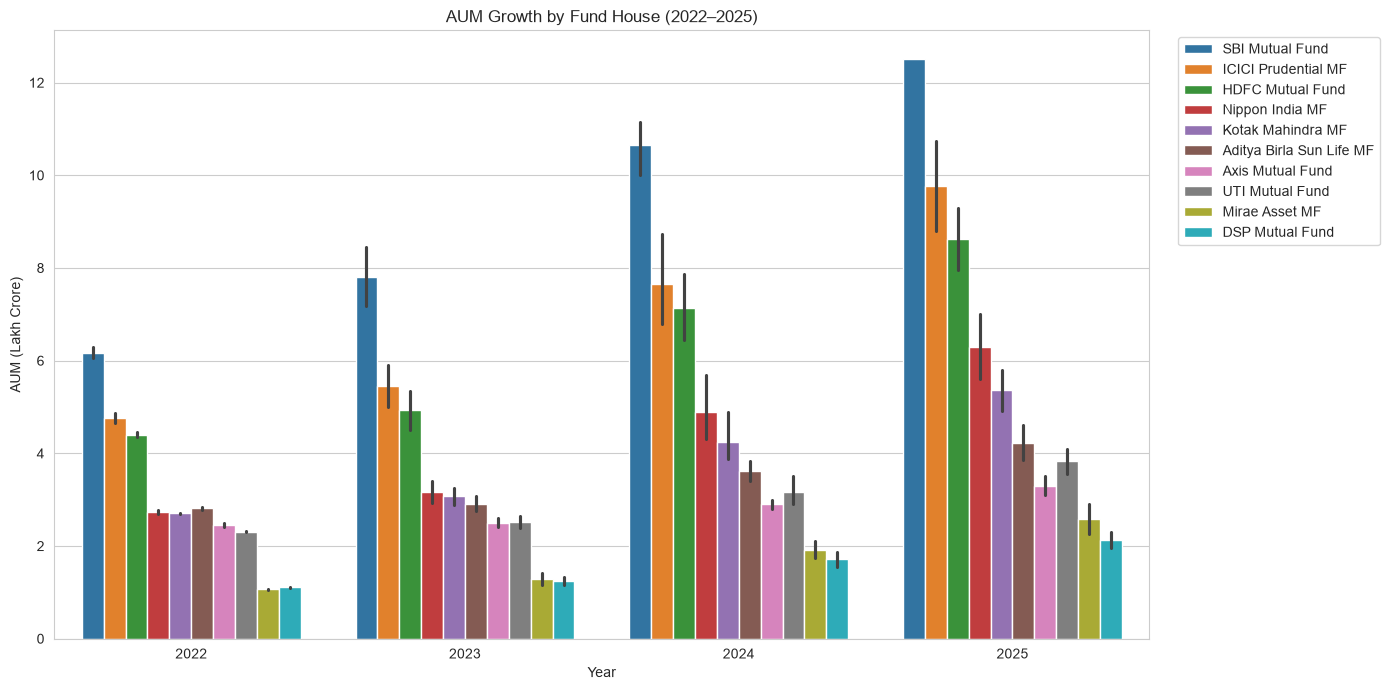

In [13]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

In [14]:
aum[aum["fund_house"].str.contains("SBI", case=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


## Insight 2

- SBI Mutual Fund consistently maintained one of the highest AUM values.
- The AUM of leading fund houses increased steadily from 2022 to 2025.
- Larger fund houses continue to dominate the mutual fund industry.

In [15]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [16]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.show()

In [17]:
highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text=f'Peak: {highest["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2
)

fig.show()

## Insight 3

- Monthly SIP inflows increased steadily from 2022 to 2025.
- The highest SIP inflow was recorded at the end of 2025.
- The consistent increase reflects growing investor confidence in mutual funds.

In [18]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


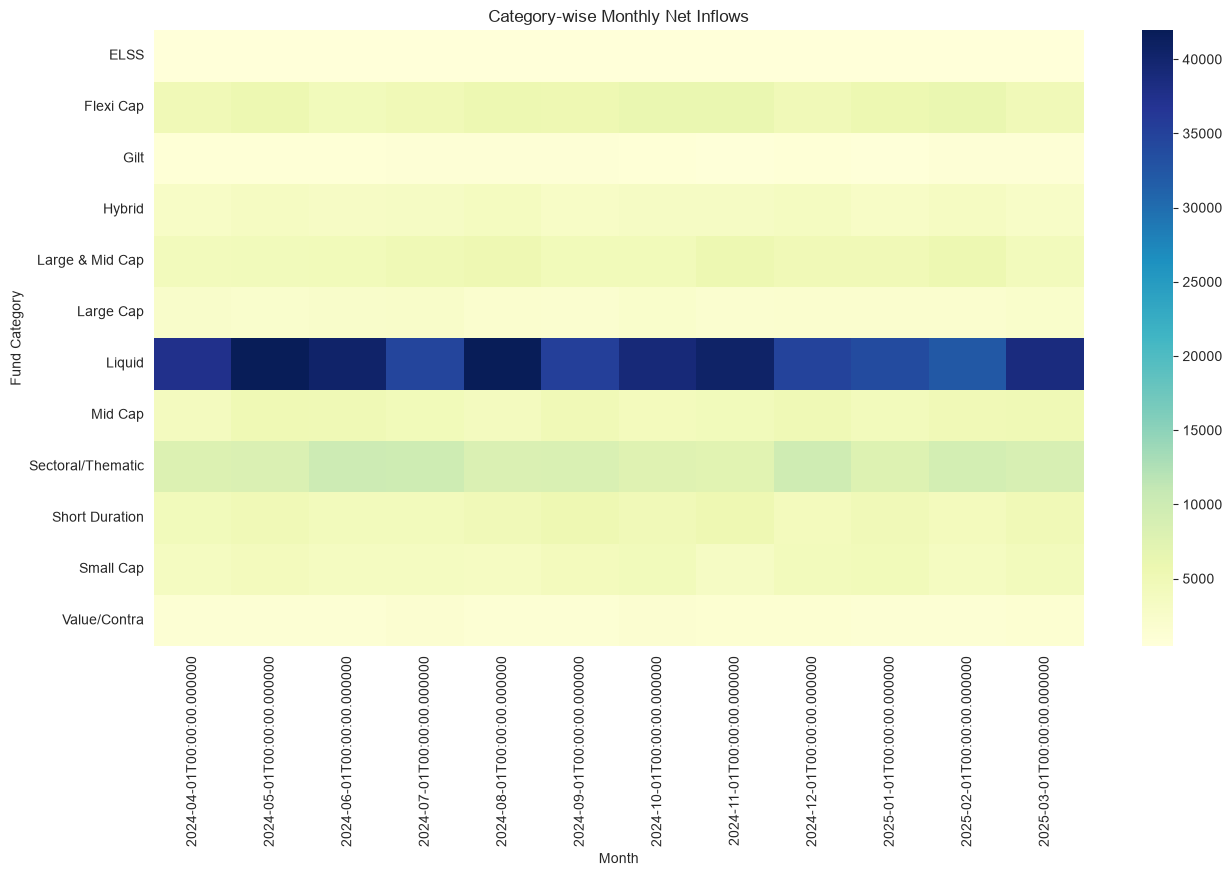

In [19]:
plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [20]:
# Convert month column to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


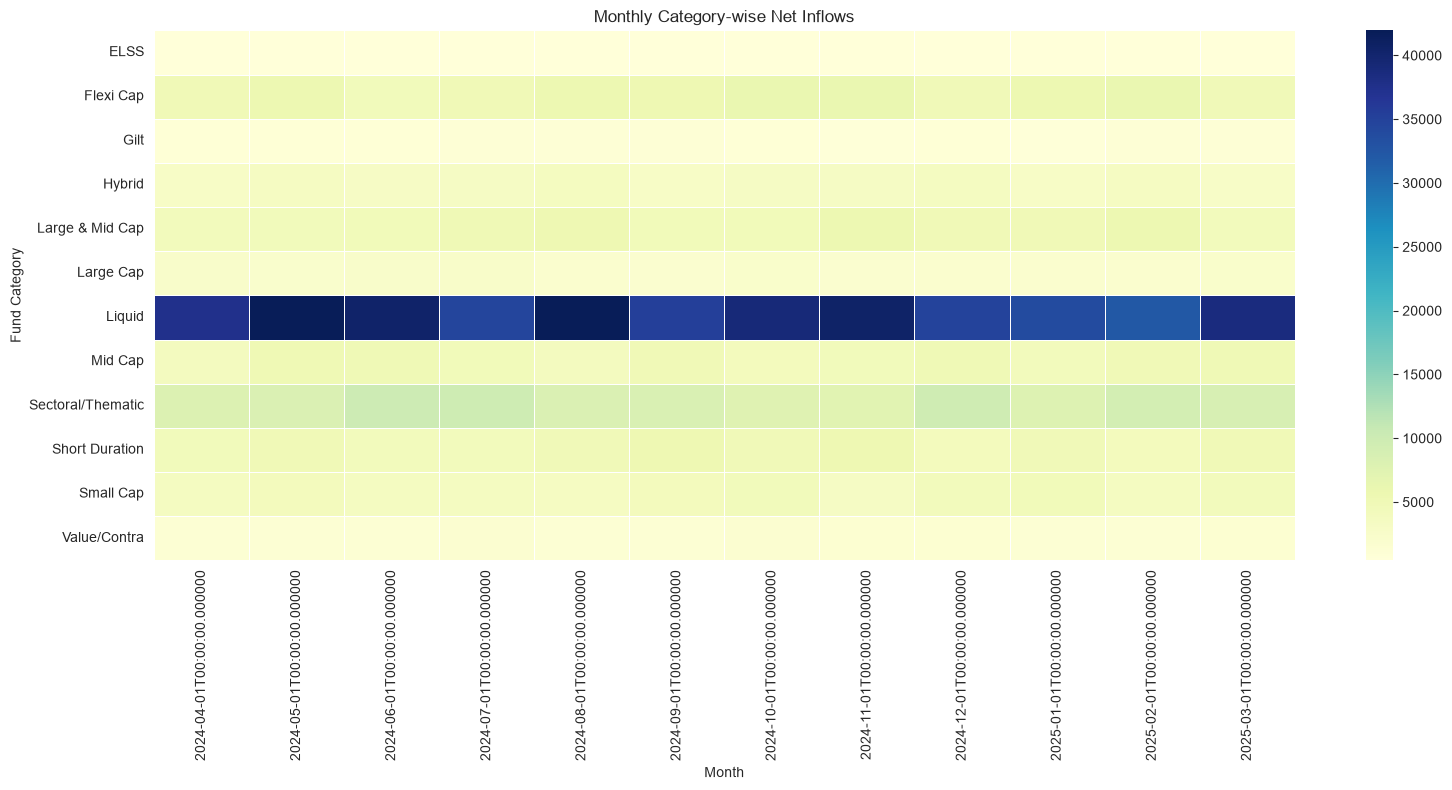

In [21]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title("Monthly Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

## Insight 4

- Equity-oriented categories received higher net inflows than several other categories.
- Monthly inflows fluctuated across categories, indicating changing investor preferences.
- Some categories showed sustained investor interest over multiple months.

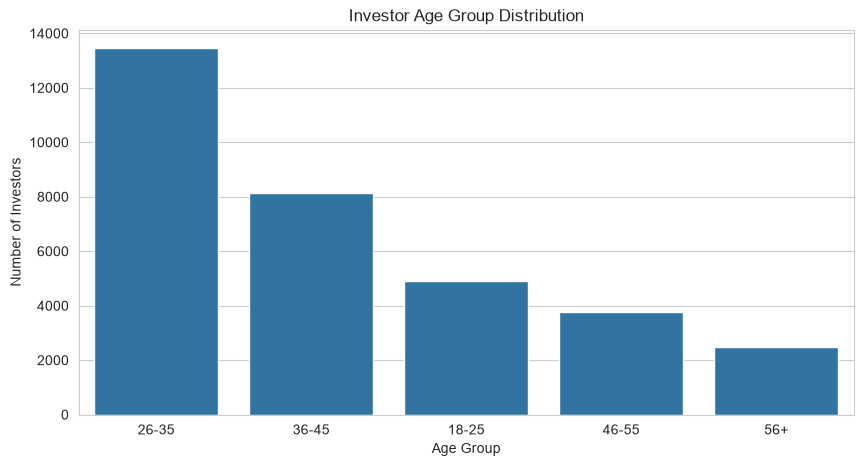

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=investor,
    x="age_group",
    order=investor["age_group"].value_counts().index
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.show()

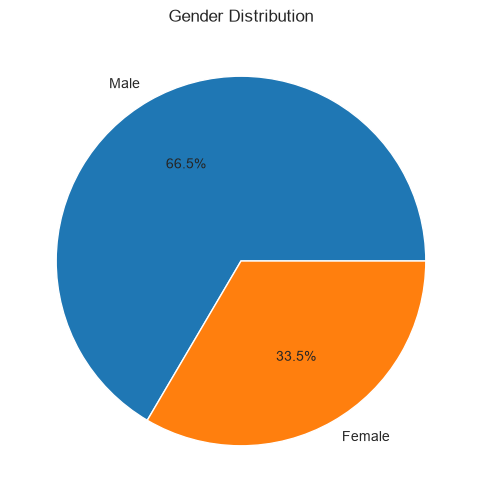

In [23]:
plt.figure(figsize=(6,6))

investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

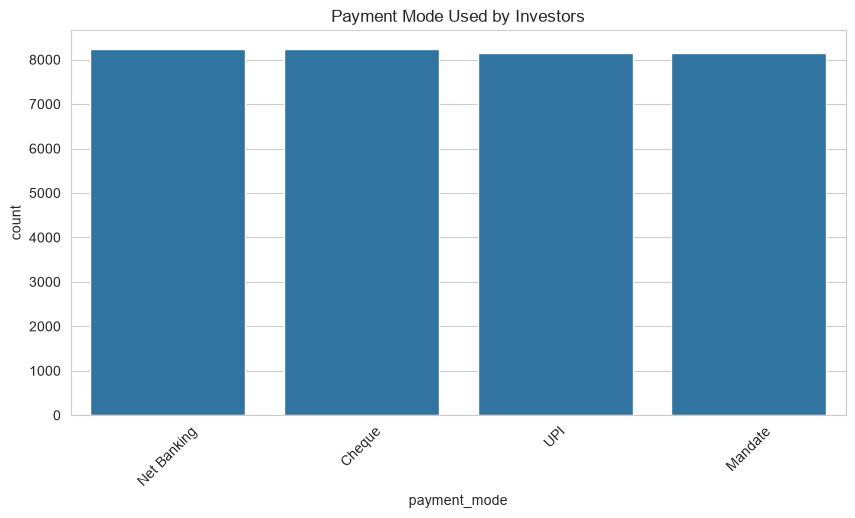

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=investor,
    x="payment_mode",
    order=investor["payment_mode"].value_counts().index
)

plt.title("Payment Mode Used by Investors")

plt.xticks(rotation=45)

plt.show()

## Insight 5

- Investors are distributed across multiple age groups.
- Digital payment methods are widely used for mutual fund investments.
- Gender participation appears reasonably balanced, with some variation across the dataset.

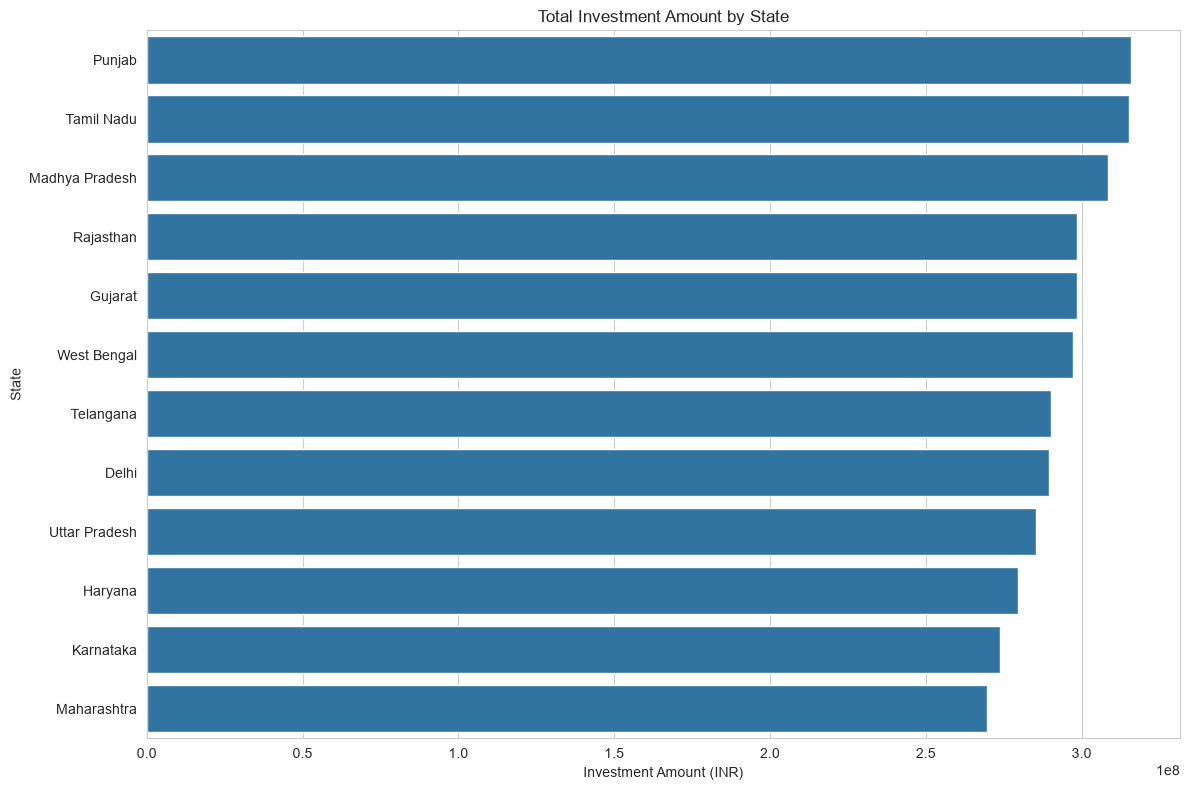

In [25]:
# Total investment amount by state
state_amount = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

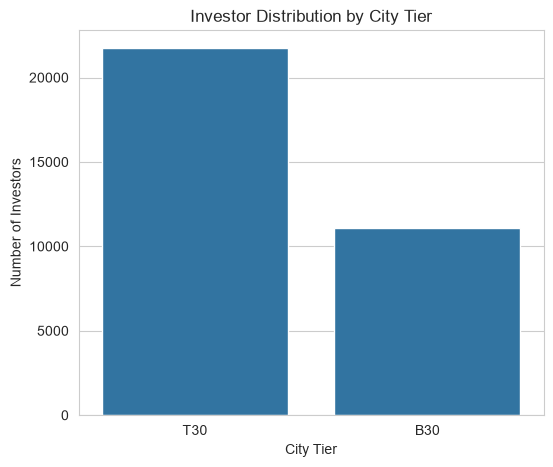

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=investor,
    x="city_tier"
)

plt.title("Investor Distribution by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Number of Investors")

plt.show()

## Insight 6

- Investments are concentrated in a few major states.
- T30 cities contribute a significant share of investors.
- B30 cities also show strong participation, indicating growing mutual fund adoption beyond metro areas.

In [27]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [28]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [29]:
folio["month"] = pd.to_datetime(folio["month"])

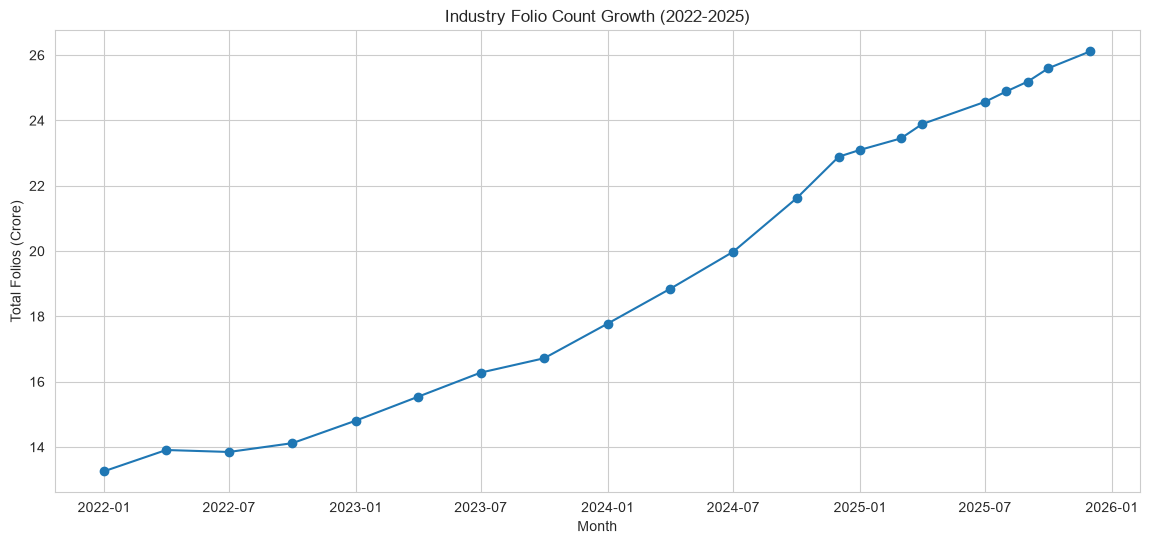

In [31]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

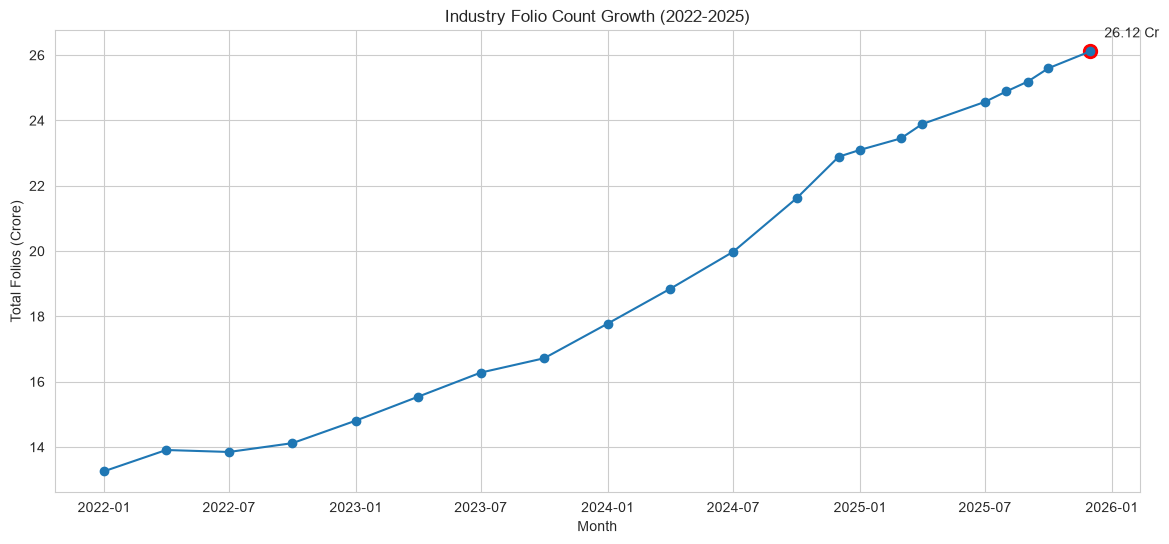

In [32]:
highest = folio.loc[folio["total_folios_crore"].idxmax()]

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.scatter(
    highest["month"],
    highest["total_folios_crore"],
    color="red",
    s=100
)

plt.annotate(
    f'{highest["total_folios_crore"]:.2f} Cr',
    (highest["month"], highest["total_folios_crore"]),
    xytext=(10,10),
    textcoords="offset points"
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.show()

## Insight 7

- Total mutual fund folios increased consistently from 2022 to 2025.
- The highest folio count was recorded at the end of 2025.
- Rising folio counts indicate increasing retail participation in mutual funds.

In [33]:
performance.corr(numeric_only=True)

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
amfi_code,1.000000,0.043089,0.125020,0.141773,0.128225,-0.068522,0.186914,-0.120338,-0.125486,0.172025,-0.328072,0.085165,0.153835,-0.002633
return_1yr_pct,0.043089,1.000000,0.910491,0.879870,0.905183,-0.195518,0.692502,-0.508997,-0.521809,0.907561,-0.457619,0.096182,0.458151,0.082746
return_3yr_pct,0.125020,0.910491,1.000000,0.929076,0.995777,-0.231775,0.732442,-0.519123,-0.531099,0.956132,-0.479871,0.062200,0.514664,0.122437
return_5yr_pct,0.141773,0.879870,0.929076,1.000000,0.926384,-0.228376,0.699485,-0.483935,-0.481465,0.940751,-0.507809,0.143765,0.456199,0.048401
benchmark_3yr_pct,0.128225,0.905183,0.995777,0.926384,1.000000,-0.320098,0.735772,-0.527800,-0.538066,0.959576,-0.482498,0.031276,0.523233,0.105584
alpha,-0.068522,-0.195518,-0.231775,-0.228376,-0.320098,1.000000,-0.237821,0.235492,0.220688,-0.300885,0.160525,0.310481,-0.233115,0.144725
beta,0.186914,0.692502,0.732442,0.699485,0.735772,-0.237821,1.000000,-0.709002,-0.711908,0.811858,-0.783988,-0.087742,0.561037,-0.009599
sharpe_ratio,-0.120338,-0.508997,-0.519123,-0.483935,-0.527800,0.235492,-0.709002,1.000000,0.991099,-0.679069,0.577159,0.185338,-0.438824,0.025097
sortino_ratio,-0.125486,-0.521809,-0.531099,-0.481465,-0.538066,0.220688,-0.711908,0.991099,1.000000,-0.686042,0.588261,0.190414,-0.459422,0.011678
std_dev_ann_pct,0.172025,0.907561,0.956132,0.940751,0.959576,-0.300885,0.811858,-0.679069,-0.686042,1.000000,-0.594780,0.027713,0.545995,0.087380


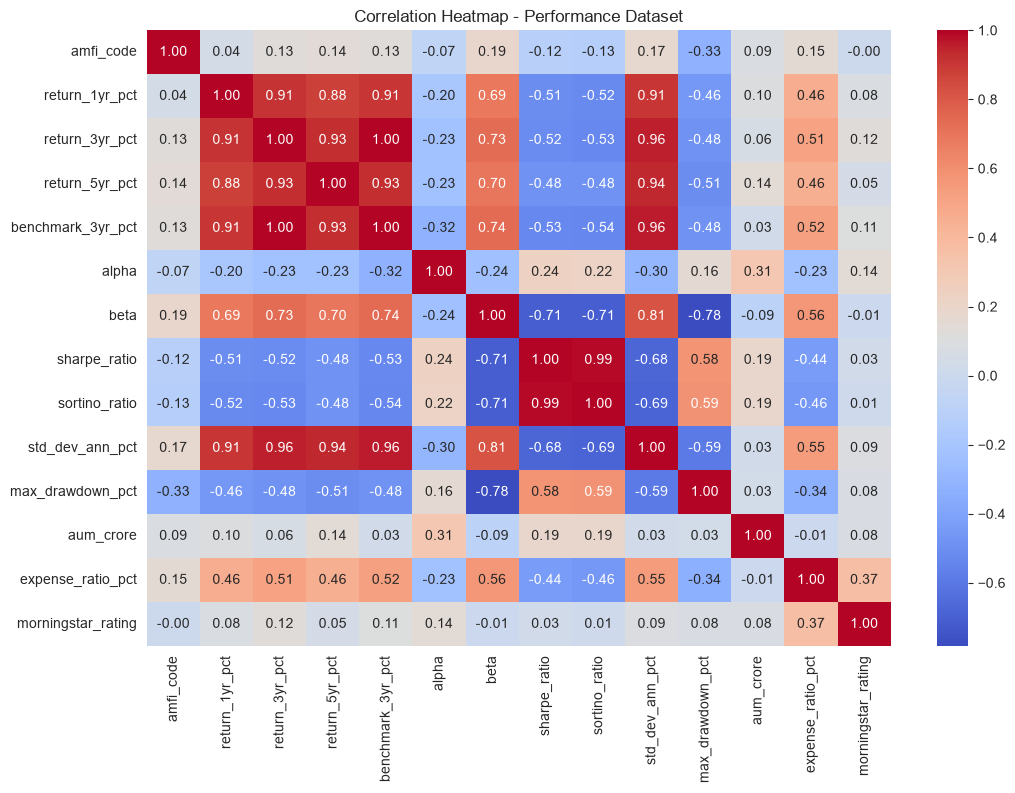

In [34]:
plt.figure(figsize=(12,8))

sns.heatmap(
    performance.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Performance Dataset")

plt.show()

## Insight 8

- Long-term returns (3-year and 5-year) show strong positive correlation.
- Risk-adjusted metrics such as Sharpe Ratio and Sortino Ratio are positively related.
- Higher volatility tends to be associated with larger drawdowns.

In [35]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [36]:
sector_data = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

sector_data.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

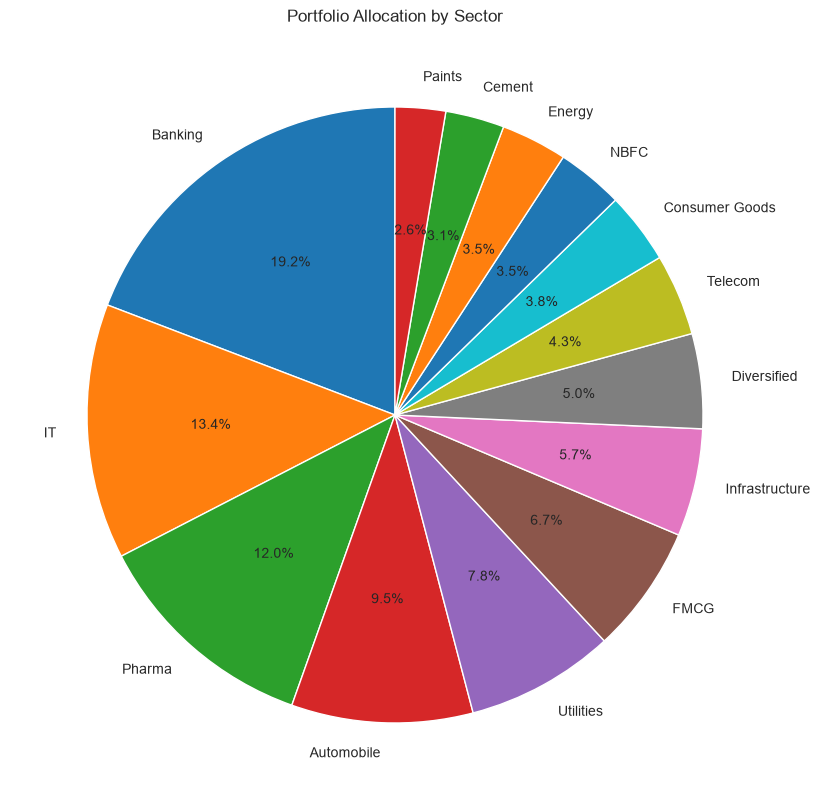

In [37]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Portfolio Allocation by Sector")

plt.show()

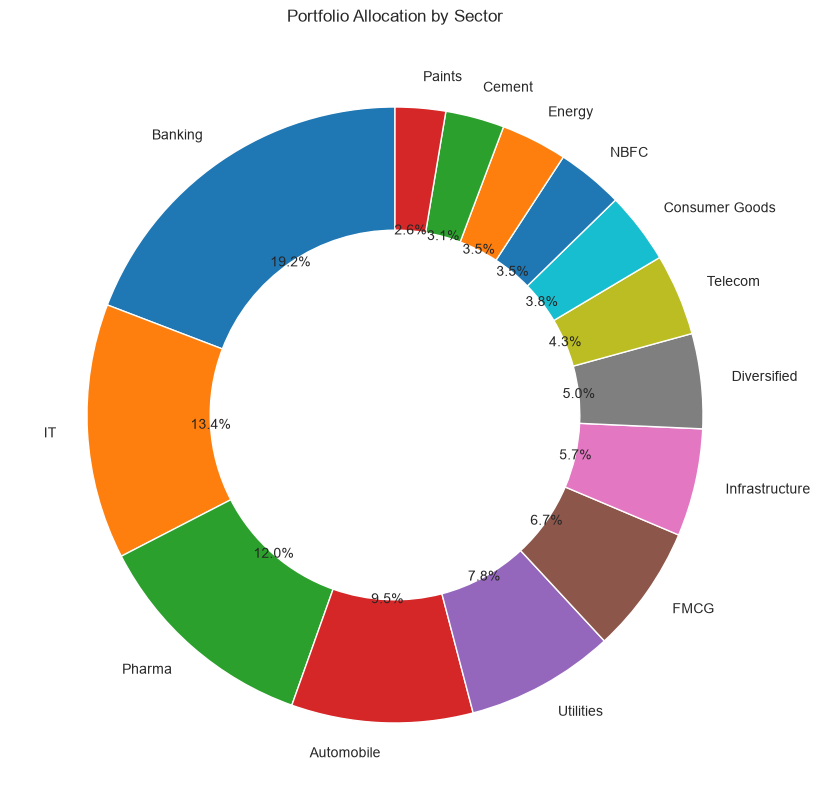

In [38]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Portfolio Allocation by Sector")

plt.show()

## Insight 9

- The portfolio is diversified across multiple sectors.
- Financials, IT, and Industrials account for a significant share of holdings.
- Sector diversification helps reduce concentration risk and improves portfolio stability.

# Conclusion

The exploratory analysis highlights strong growth in India's mutual fund industry between 2022 and 2025.

Key findings include:

- NAV values generally increased over time.
- AUM continued to grow across major fund houses.
- SIP inflows reached record highs in 2025.
- Equity-oriented categories attracted significant investments.
- Retail participation increased steadily.
- Portfolio allocations remained diversified across sectors.
- Risk-adjusted performance metrics showed meaningful correlations.

Overall, the mutual fund industry demonstrated consistent growth, increasing investor participation, and healthy diversification during the analysis period.